# V-JEPA 2.1 Vacancy / Blight Proxy Fine-tuning — Clean v4 with Original-vs-Fine-tuned Comparison

This notebook compares two outputs on the same validation set:

1. **Original pretrained V-JEPA 2.1 output**  
   Frozen V-JEPA embeddings are used directly with a no-gradient class-prototype classifier.
   This is a lightweight way to inspect what the original pretrained representation can separate
   before any downstream head is trained.

2. **Fine-tuned downstream output**  
   V-JEPA remains frozen, and only a small MLP head is trained on top of V-JEPA clip embeddings.

Important clarification:

```text
This notebook does not update the V-JEPA 2.1 backbone weights.
It fine-tunes only the downstream MLP head.
```

Task:

```text
Baltimore vacant-building notices
+ nearby hard negatives
+ aerial image chips
+ V-JEPA 2.1 frozen encoder
→ compare original embedding baseline vs fine-tuned head
```

Recommended first run on Colab T4:

```text
MAX_POSITIVES = 100
MAX_NEGATIVES = 100
IMAGERY_ZOOM = 18
T_FRAMES = 8
BATCH_SIZE = 2
EPOCHS = 3
```

## 0. Install dependencies


In [1]:
# -----------------------------------------------------------------------------
# Step 0. Install dependencies
# -----------------------------------------------------------------------------
# This cell installs the geospatial and deep-learning dependencies required by
# the notebook. It is intended for a fresh Colab runtime. The core workflow uses
# GeoPandas/Shapely/PyProj for spatial data handling, PIL/requests for imagery
# download, and PyTorch/torchvision for V-JEPA feature extraction and downstream
# head training.
# -----------------------------------------------------------------------------

# Run once in a fresh Colab runtime.
# If you already have CUDA-enabled torch installed, do not reinstall torch here.

%pip install -q geopandas shapely pyproj requests tqdm matplotlib scikit-learn pillow pandas numpy nbformat
%pip install -q timm einops

import sys
print(sys.version)


3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## 1. Imports and configuration


In [2]:
# -----------------------------------------------------------------------------
# Step 1. Imports and configuration
# -----------------------------------------------------------------------------
# This cell defines the notebook-wide runtime configuration:
# - imports for file I/O, numerical processing, geospatial operations, imagery,
#   plotting, and HTTP access;
# - deterministic seeds for reproducible sampling and train/validation splits;
# - project directories and cached artifact paths;
# - data limits for a small, fast prototype;
# - hard-negative sampling distances;
# - Esri imagery download policy, explicitly requiring real imagery and disabling
#   synthetic fallback;
# - V-JEPA input size, pseudo-video frame count, head-training hyperparameters,
#   and the official V-JEPA 2.1 ViT-B/384 checkpoint URL.
#
# No model training happens here. This is the central configuration layer used by
# all later cells.
# -----------------------------------------------------------------------------

from __future__ import annotations

from pathlib import Path
from io import BytesIO
import os
import math
import json
import time
import random
import warnings

import numpy as np
import pandas as pd
import requests
from PIL import Image
from tqdm.auto import tqdm

import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
from pyproj import Transformer

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path("vjepa21_vacancy_clean_v3")
DATA_DIR = PROJECT_DIR / "data"
CHIP_DIR = DATA_DIR / "chips_esri_fast_v3"
OUT_DIR = PROJECT_DIR / "outputs"
CKPT_DIR = OUT_DIR / "checkpoints"
FIG_DIR = OUT_DIR / "figures"

for d in [DATA_DIR, CHIP_DIR, OUT_DIR, CKPT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

POS_PATH = DATA_DIR / "baltimore_vbn_positive.geojson"
DATASET_PATH = DATA_DIR / "dataset_hard_negative.geojson"
MANIFEST_PATH = DATA_DIR / "manifest_esri_fast_v3.csv"
SPLIT_PATH = DATA_DIR / "manifest_split_esri_fast_v3.csv"

BALTIMORE_VBN_ITEM_ID = "691d65a5f85640e6aaa46930bd9dc102"

MAX_POSITIVES = 100
MAX_NEGATIVES = 100

NEG_MIN_DISTANCE_M = 120
NEG_MAX_DISTANCE_M = 450
NEG_MAX_ATTEMPTS_PER_SAMPLE = 100

TRAIN_RATIO = 0.8
GRID_SIZE_M = 700

DOWNLOAD_IMAGERY = True
REQUIRE_REAL_IMAGERY = True
ALLOW_SYNTHETIC_FALLBACK = False

IMG_SIZE = 384
IMAGERY_ZOOM = 18

T_FRAMES = 8
BATCH_SIZE = 2
EPOCHS = 3
LR_HEAD = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

VJEPA21_VITB_CKPT_URL = "https://dl.fbaipublicfiles.com/vjepa2/vjepa2_1_vitb_dist_vitG_384.pt"

print("PROJECT_DIR:", PROJECT_DIR.resolve())
print("DATA_DIR:", DATA_DIR.resolve())
print("CHIP_DIR:", CHIP_DIR.resolve())


PROJECT_DIR: /content/vjepa21_vacancy_clean_v3
DATA_DIR: /content/vjepa21_vacancy_clean_v3/data
CHIP_DIR: /content/vjepa21_vacancy_clean_v3/data/chips_esri_fast_v3


## 2. Fetch Baltimore Vacant Building Notices


In [3]:
# -----------------------------------------------------------------------------
# Step 2. Fetch Baltimore Vacant Building Notices
# -----------------------------------------------------------------------------
# This cell retrieves the Baltimore Vacant Building Notices dataset from ArcGIS
# and converts it into the positive class for the downstream task.
#
# Conceptually:
#   ArcGIS item ID
#   -> resolve the Feature Service URL
#   -> query the feature layer as GeoJSON
#   -> keep valid geometries
#   -> assign label=1 and source='vacant_building_notice'
#   -> cache the result as a GeoJSON file.
#
# These records are weak positive labels: the model is not given hand-labeled
# image chips, but geographic points associated with vacant-building notices.
# Later cells download imagery around these points.
# -----------------------------------------------------------------------------

def resolve_arcgis_feature_service(item_id: str) -> str:
    meta_url = f"https://www.arcgis.com/sharing/rest/content/items/{item_id}"
    r = requests.get(meta_url, params={"f": "json"}, timeout=60)
    r.raise_for_status()
    meta = r.json()

    print("ArcGIS item title:", meta.get("title"))
    print("ArcGIS item type :", meta.get("type"))

    service_url = meta.get("url")
    if not service_url:
        raise RuntimeError(f"No service url found in item metadata. Keys: {list(meta.keys())}")

    return service_url.rstrip("/")


def query_arcgis_layer(service_url: str, layer_id: int | None = None, max_records: int = 1000) -> gpd.GeoDataFrame:
    service_url = service_url.rstrip("/")
    if service_url.split("/")[-1].isdigit():
        layer_url = service_url
    else:
        if layer_id is None:
            layer_id = 0
        layer_url = f"{service_url}/{layer_id}"

    query_url = f"{layer_url}/query"
    params = {
        "f": "geojson",
        "where": "1=1",
        "outFields": "*",
        "returnGeometry": "true",
        "resultRecordCount": max_records,
        "outSR": 4326,
    }
    r = requests.get(query_url, params=params, timeout=120)
    print("Query URL:", r.url)
    r.raise_for_status()

    geojson = r.json()
    if "features" not in geojson:
        raise RuntimeError(f"Unexpected ArcGIS response: {geojson}")

    return gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")


if POS_PATH.exists():
    pos_gdf = gpd.read_file(POS_PATH)
    print("Loaded cached positives:", pos_gdf.shape)
else:
    feature_service_url = resolve_arcgis_feature_service(BALTIMORE_VBN_ITEM_ID)
    print("Feature service:", feature_service_url)

    pos_gdf = query_arcgis_layer(feature_service_url, layer_id=None, max_records=MAX_POSITIVES)
    pos_gdf = pos_gdf[pos_gdf.geometry.notnull()].copy().to_crs("EPSG:4326")
    pos_gdf["label"] = 1
    pos_gdf["source"] = "vacant_building_notice"
    pos_gdf = pos_gdf[["geometry", "label", "source"]].copy()
    pos_gdf.to_file(POS_PATH, driver="GeoJSON")
    print("Saved positives:", POS_PATH)

print("pos_gdf shape:", pos_gdf.shape)
display(pos_gdf.head())


ArcGIS item title: Vacant Building Notices
ArcGIS item type : Feature Service
Feature service: https://egisdata.baltimorecity.gov/egis/rest/services/Housing/DHCD_Open_Baltimore_Datasets/FeatureServer/1
Query URL: https://egisdata.baltimorecity.gov/egis/rest/services/Housing/DHCD_Open_Baltimore_Datasets/FeatureServer/1/query?f=geojson&where=1%3D1&outFields=%2A&returnGeometry=true&resultRecordCount=100&outSR=4326
Saved positives: vjepa21_vacancy_clean_v3/data/baltimore_vbn_positive.geojson
pos_gdf shape: (100, 3)


,geometry,label,source
0,POINT (-76.64934 39.28088),1,vacant_building_notice
1,POINT (-76.64916 39.28094),1,vacant_building_notice
2,POINT (-76.64778 39.28138),1,vacant_building_notice
3,POINT (-76.64783 39.28136),1,vacant_building_notice
4,POINT (-76.64797 39.28132),1,vacant_building_notice


## 3. Create nearby hard negatives


In [4]:
# -----------------------------------------------------------------------------
# Step 3. Create nearby hard negatives
# -----------------------------------------------------------------------------
# This cell creates proxy negative samples near the positive VBN points.
#
# Instead of drawing random negatives from the whole city, it samples points in a
# distance band around positive locations. The goal is to make the binary task
# harder and reduce trivial shortcuts such as broad neighborhood, density, or
# acquisition-condition differences.
#
# Key design:
# - transform to EPSG:3857 so distances are approximately measured in meters;
# - exclude candidates inside a minimum-distance buffer around any positive point;
# - sample candidates within a min/max distance ring;
# - assign label=0 and source='nearby_hard_negative_proxy';
# - combine positives and negatives into a single GeoDataFrame;
# - add sample_id and grid_id fields for later imagery naming and spatial split.
#
# These negatives are proxy negatives, not verified non-vacant buildings. The
# evaluation should therefore be interpreted as VBN-point vs nearby-hard-negative
# separation, not definitive vacant-building detection.
# -----------------------------------------------------------------------------

def sample_hard_negative_points_nearby(
    pos_gdf: gpd.GeoDataFrame,
    n: int,
    min_distance_m: float = NEG_MIN_DISTANCE_M,
    max_distance_m: float = NEG_MAX_DISTANCE_M,
    max_attempts_per_sample: int = NEG_MAX_ATTEMPTS_PER_SAMPLE,
) -> gpd.GeoDataFrame:
    if len(pos_gdf) == 0:
        raise RuntimeError("pos_gdf is empty.")

    pos_3857 = pos_gdf.to_crs("EPSG:3857").reset_index(drop=True)
    positive_buffer = unary_union(pos_3857.geometry.buffer(min_distance_m))

    samples = []
    attempts = 0
    max_attempts = max(n * max_attempts_per_sample, 1000)

    while len(samples) < n and attempts < max_attempts:
        attempts += 1
        base = pos_3857.geometry.iloc[random.randrange(len(pos_3857))]
        angle = random.uniform(0, 2 * math.pi)
        dist = random.uniform(min_distance_m, max_distance_m)
        p = Point(base.x + math.cos(angle) * dist, base.y + math.sin(angle) * dist)
        if positive_buffer.contains(p):
            continue
        samples.append(p)

    if len(samples) < n:
        warnings.warn(f"Only sampled {len(samples)} negatives out of requested {n}.")

    return gpd.GeoDataFrame(
        {"label": [0] * len(samples), "source": ["nearby_hard_negative_proxy"] * len(samples)},
        geometry=samples,
        crs="EPSG:3857",
    ).to_crs("EPSG:4326")


if DATASET_PATH.exists():
    dataset_gdf = gpd.read_file(DATASET_PATH)
    print("Loaded cached dataset:", dataset_gdf.shape)
else:
    if "pos_gdf" not in globals():
        if POS_PATH.exists():
            pos_gdf = gpd.read_file(POS_PATH)
        else:
            raise RuntimeError("pos_gdf is missing. Run Step 2 first.")

    pos_sample = pos_gdf.sample(n=min(MAX_POSITIVES, len(pos_gdf)), random_state=SEED).copy()
    pos_sample["label"] = 1
    pos_sample["source"] = "vacant_building_notice"
    neg_gdf = sample_hard_negative_points_nearby(pos_sample, n=MAX_NEGATIVES)

    dataset_gdf = pd.concat(
        [pos_sample[["geometry", "label", "source"]], neg_gdf[["geometry", "label", "source"]]],
        ignore_index=True,
    )
    dataset_gdf = gpd.GeoDataFrame(dataset_gdf, geometry="geometry", crs="EPSG:4326")
    dataset_gdf["sample_id"] = [f"sample_{i:06d}" for i in range(len(dataset_gdf))]

    tmp = dataset_gdf.to_crs("EPSG:3857")
    dataset_gdf["x_3857"] = tmp.geometry.x
    dataset_gdf["y_3857"] = tmp.geometry.y
    dataset_gdf["grid_x"] = np.floor(dataset_gdf["x_3857"] / GRID_SIZE_M).astype(int)
    dataset_gdf["grid_y"] = np.floor(dataset_gdf["y_3857"] / GRID_SIZE_M).astype(int)
    dataset_gdf["grid_id"] = dataset_gdf["grid_x"].astype(str) + "_" + dataset_gdf["grid_y"].astype(str)
    dataset_gdf.to_file(DATASET_PATH, driver="GeoJSON")
    print("Saved dataset:", DATASET_PATH)

print("dataset_gdf shape:", dataset_gdf.shape)
print(dataset_gdf["label"].value_counts())
print("unique grids:", dataset_gdf["grid_id"].nunique())
display(dataset_gdf.head())


Saved dataset: vjepa21_vacancy_clean_v3/data/dataset_hard_negative.geojson
dataset_gdf shape: (200, 9)
label
1    100
0    100
Name: count, dtype: int64
unique grids: 19


,geometry,label,source,sample_id,x_3857,y_3857,grid_x,grid_y,grid_id
0,POINT (-76.64267 39.28308),1,vacant_building_notice,sample_000000,-8.531823e+06,4.762302e+06,-12189,6803,-12189_6803
1,POINT (-76.6416 39.28377),1,vacant_building_notice,sample_000001,-8.531703e+06,4.762402e+06,-12189,6803,-12189_6803
2,POINT (-76.63981 39.28361),1,vacant_building_notice,sample_000002,-8.531505e+06,4.762378e+06,-12188,6803,-12188_6803
3,POINT (-76.65229 39.28218),1,vacant_building_notice,sample_000003,-8.532894e+06,4.762172e+06,-12190,6803,-12190_6803
4,POINT (-76.65228 39.2821),1,vacant_building_notice,sample_000004,-8.532893e+06,4.762161e+06,-12190,6803,-12190_6803


## 4. Download fast Esri imagery tiles and build manifest


In [5]:
# -----------------------------------------------------------------------------
# Step 4. Download fast Esri imagery tiles and build manifest
# -----------------------------------------------------------------------------
# This cell turns the geospatial dataset into an image dataset.
#
# For each sample point, it:
# - converts longitude/latitude to a Web Mercator tile coordinate;
# - downloads the corresponding Esri World Imagery tile;
# - resizes the tile to the V-JEPA input size;
# - saves it under a sample_id-based filename;
# - builds a manifest CSV linking chip_path, label, sample_id, grid_id, lon/lat,
#   and image_source.
#
# The implementation intentionally requires real Esri imagery and rejects
# synthetic fallback, because mixing dummy images into the dataset would make the
# original-vs-fine-tuned comparison invalid.
#
# Note: this fast tile method downloads the tile containing the target point. It
# does not guarantee a point-centered crop. It is chosen here for speed and
# simplicity in an MVP workflow.
# -----------------------------------------------------------------------------

def lonlat_to_tile(lon: float, lat: float, zoom: int) -> tuple[int, int]:
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    x = int((lon + 180.0) / 360.0 * n)
    y = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return x, y


def make_neutral_synthetic_chip(size: int = IMG_SIZE, seed: int = 0) -> Image.Image:
    rng = np.random.default_rng(seed)
    base = rng.normal(loc=128, scale=28, size=(size, size, 3)).clip(0, 255).astype(np.uint8)
    return Image.fromarray(base).convert("RGB")


def download_chip_fast_esri_tile(lon: float, lat: float, out_path: Path, zoom: int = IMAGERY_ZOOM) -> Path:
    x, y = lonlat_to_tile(lon, lat, zoom)
    url = "https://server.arcgisonline.com/ArcGIS/rest/services/" + f"World_Imagery/MapServer/tile/{zoom}/{y}/{x}"
    headers = {"User-Agent": "Mozilla/5.0 VJEPA-Vacancy-Practice"}
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    img = Image.open(BytesIO(r.content)).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE), resample=Image.Resampling.BILINEAR)
    img.save(out_path)
    return out_path


if MANIFEST_PATH.exists():
    manifest = pd.read_csv(MANIFEST_PATH)
    print("Loaded cached manifest:", manifest.shape)
else:
    if "dataset_gdf" not in globals():
        if DATASET_PATH.exists():
            dataset_gdf = gpd.read_file(DATASET_PATH)
        else:
            raise RuntimeError("dataset_gdf is missing. Run Step 3 first.")

    records = []
    failed = []
    for i, row in tqdm(dataset_gdf.iterrows(), total=len(dataset_gdf), desc="Downloading Esri tiles"):
        out_path = CHIP_DIR / f"{row.sample_id}.png"
        if out_path.exists():
            image_source = "cache"
        else:
            try:
                if DOWNLOAD_IMAGERY:
                    download_chip_fast_esri_tile(row.geometry.x, row.geometry.y, out_path, zoom=IMAGERY_ZOOM)
                    image_source = "esri_world_imagery_fast_tile"
                else:
                    if not ALLOW_SYNTHETIC_FALLBACK:
                        raise RuntimeError("DOWNLOAD_IMAGERY=False but synthetic fallback is disabled.")
                    make_neutral_synthetic_chip(seed=i).save(out_path)
                    image_source = "neutral_synthetic_debug"
            except Exception as e:
                failed.append((row.sample_id, str(e)))
                if REQUIRE_REAL_IMAGERY:
                    raise RuntimeError(
                        f"Real imagery download failed for {row.sample_id}. "
                        "Do not continue because synthetic fallback would invalidate evaluation. "
                        f"Original error: {e}"
                    ) from e
                if ALLOW_SYNTHETIC_FALLBACK:
                    make_neutral_synthetic_chip(seed=i).save(out_path)
                    image_source = "neutral_synthetic_debug"
                else:
                    continue

        base = row.drop(labels="geometry").to_dict()
        records.append({**base, "chip_path": str(out_path), "lon": row.geometry.x, "lat": row.geometry.y, "image_source": image_source})

    manifest = pd.DataFrame(records)
    if len(manifest) == 0:
        raise RuntimeError("No image chips were created.")
    if REQUIRE_REAL_IMAGERY:
        allowed = {"esri_world_imagery_fast_tile", "cache"}
        non_real = manifest[~manifest["image_source"].isin(allowed)]
        if len(non_real) > 0:
            raise RuntimeError(f"Non-real imagery rows detected: {non_real['image_source'].value_counts().to_dict()}")
    manifest.to_csv(MANIFEST_PATH, index=False)
    print("Saved manifest:", MANIFEST_PATH)

print("manifest shape:", manifest.shape)
print("label counts:")
print(manifest["label"].value_counts())
print("image_source counts:")
print(manifest["image_source"].value_counts())
display(manifest.head())


Saved manifest: vjepa21_vacancy_clean_v3/data/manifest_esri_fast_v3.csv
manifest shape: (200, 12)
label counts:
label
1    100
0    100
Name: count, dtype: int64
image_source counts:
image_source
esri_world_imagery_fast_tile    200
Name: count, dtype: int64


,label,source,sample_id,x_3857,y_3857,grid_x,grid_y,grid_id,chip_path,lon,lat,image_source
0,1,vacant_building_notice,sample_000000,-8.531823e+06,4.762302e+06,-12189,6803,-12189_6803,vjepa21_vacancy_clean_v3/data/chips_esri_fast_...,-76.642672,39.283082,esri_world_imagery_fast_tile
1,1,vacant_building_notice,sample_000001,-8.531703e+06,4.762402e+06,-12189,6803,-12189_6803,vjepa21_vacancy_clean_v3/data/chips_esri_fast_...,-76.641595,39.283774,esri_world_imagery_fast_tile
2,1,vacant_building_notice,sample_000002,-8.531505e+06,4.762378e+06,-12188,6803,-12188_6803,vjepa21_vacancy_clean_v3/data/chips_esri_fast_...,-76.639810,39.283608,esri_world_imagery_fast_tile
3,1,vacant_building_notice,sample_000003,-8.532894e+06,4.762172e+06,-12190,6803,-12190_6803,vjepa21_vacancy_clean_v3/data/chips_esri_fast_...,-76.652289,39.282180,esri_world_imagery_fast_tile
4,1,vacant_building_notice,sample_000004,-8.532893e+06,4.762161e+06,-12190,6803,-12190_6803,vjepa21_vacancy_clean_v3/data/chips_esri_fast_...,-76.652285,39.282103,esri_world_imagery_fast_tile


## 5. Preview chips


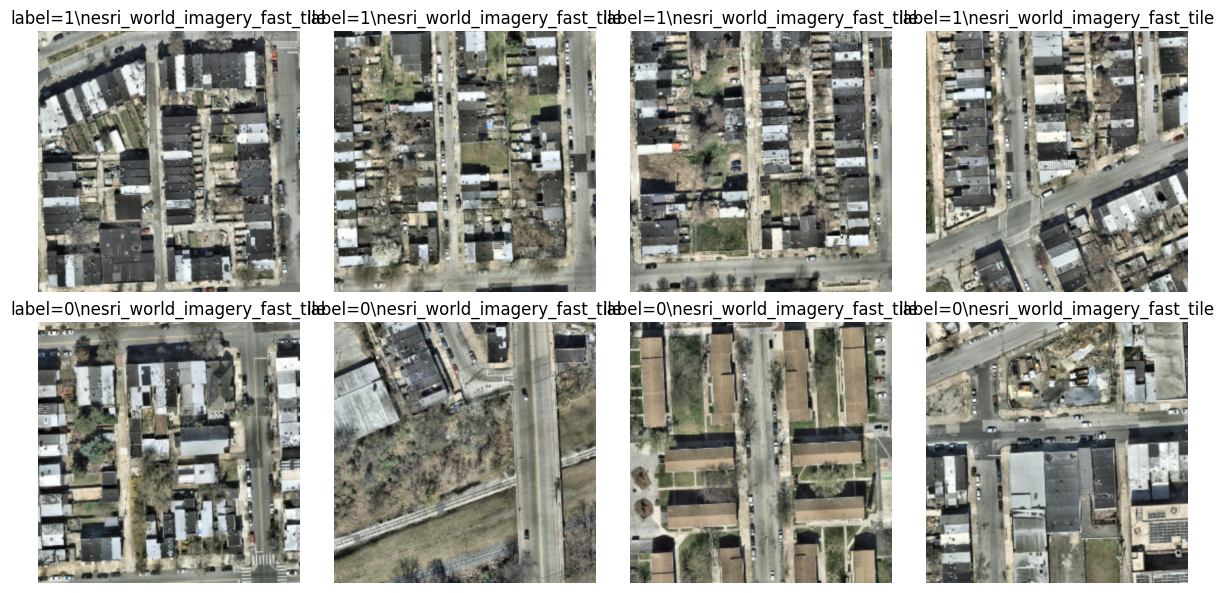

In [6]:
# -----------------------------------------------------------------------------
# Step 5. Preview chips
# -----------------------------------------------------------------------------
# This cell visually inspects a small set of downloaded image chips.
#
# It loads the manifest, selects a few examples from each label, opens the chip
# images from disk, and displays them with their label and image_source. This is
# a pre-training quality-control step.
#
# Things to check visually:
# - images are real aerial imagery, not blank/corrupted/synthetic placeholders;
# - both hard-negative and VBN samples appear;
# - the positive/negative examples are not trivially separable by obvious global
#   artifacts;
# - the chip contents are plausible for the intended Baltimore urban setting.
# -----------------------------------------------------------------------------

if "manifest" not in globals():
    if MANIFEST_PATH.exists():
        manifest = pd.read_csv(MANIFEST_PATH)
        print("Loaded manifest:", manifest.shape)
    else:
        raise RuntimeError("manifest is missing. Run Step 4 first.")

preview = manifest.groupby("label").head(4).reset_index(drop=True)
plt.figure(figsize=(12, 6))
for i, row in preview.iterrows():
    img = Image.open(row.chip_path).convert("RGB")
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"label={row.label}\\n{row.image_source}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Spatial train / validation split


In [7]:
# -----------------------------------------------------------------------------
# Step 6. Spatial train / validation split
# -----------------------------------------------------------------------------
# This cell creates a train/validation split using spatial grid IDs rather than
# ordinary row-level random sampling.
#
# The reason is spatial leakage: nearby aerial-image samples can share streets,
# buildings, acquisition artifacts, and neighborhood context. If nearby points are
# split randomly across train and validation, validation accuracy may be overly
# optimistic.
#
# The split procedure:
# - uses grid_id from Step 3;
# - assigns whole grid cells to either train or validation;
# - tries multiple random grid assignments;
# - prefers splits close to the target train ratio and with reasonable class
#   balance in both train and validation;
# - verifies that train and validation grid IDs do not overlap.
# -----------------------------------------------------------------------------

def make_spatial_split(manifest: pd.DataFrame, train_ratio: float = TRAIN_RATIO, seed: int = SEED, max_trials: int = 500) -> pd.DataFrame:
    if "grid_id" not in manifest.columns:
        raise RuntimeError("manifest must contain grid_id. Re-run Step 3 and Step 4.")
    rng = np.random.default_rng(seed)
    grids = np.array(sorted(manifest["grid_id"].unique()))
    if len(grids) < 2:
        raise RuntimeError("Not enough spatial grids for spatial holdout.")
    best = None
    best_score = float("inf")
    global_pos_rate = manifest["label"].mean()
    for _ in range(max_trials):
        shuffled = grids.copy()
        rng.shuffle(shuffled)
        n_train_grids = max(1, int(len(shuffled) * train_ratio))
        train_grids = set(shuffled[:n_train_grids])
        tmp = manifest.copy()
        tmp["split"] = np.where(tmp["grid_id"].isin(train_grids), "train", "val")
        train = tmp[tmp["split"] == "train"]
        val = tmp[tmp["split"] == "val"]
        if len(train) == 0 or len(val) == 0:
            continue
        if train["label"].nunique() < 2 or val["label"].nunique() < 2:
            continue
        size_score = abs(len(train) / len(tmp) - train_ratio)
        label_score = abs(train["label"].mean() - global_pos_rate) + abs(val["label"].mean() - global_pos_rate)
        score = size_score + label_score
        if score < best_score:
            best_score = score
            best = tmp
    if best is None:
        warnings.warn("Could not find a balanced spatial split. Falling back to grid split without label guarantees.")
        shuffled = grids.copy()
        rng.shuffle(shuffled)
        n_train_grids = max(1, int(len(shuffled) * train_ratio))
        train_grids = set(shuffled[:n_train_grids])
        best = manifest.copy()
        best["split"] = np.where(best["grid_id"].isin(train_grids), "train", "val")
    return best

if SPLIT_PATH.exists():
    manifest_split = pd.read_csv(SPLIT_PATH)
    print("Loaded cached split:", manifest_split.shape)
else:
    if "manifest" not in globals():
        if MANIFEST_PATH.exists():
            manifest = pd.read_csv(MANIFEST_PATH)
        else:
            raise RuntimeError("manifest is missing. Run Step 4 first.")
    manifest_split = make_spatial_split(manifest)
    manifest_split.to_csv(SPLIT_PATH, index=False)
    print("Saved split:", SPLIT_PATH)

train_df = manifest_split[manifest_split["split"] == "train"].copy()
val_df = manifest_split[manifest_split["split"] == "val"].copy()
overlap = set(train_df["grid_id"]) & set(val_df["grid_id"])
print("train:", train_df.shape)
print(train_df["label"].value_counts())
print("val:", val_df.shape)
print(val_df["label"].value_counts())
print("grid overlap:", len(overlap))
print("train positive rate:", train_df["label"].mean())
print("val positive rate:", val_df["label"].mean())
display(manifest_split.head())


Saved split: vjepa21_vacancy_clean_v3/data/manifest_split_esri_fast_v3.csv
train: (160, 13)
label
1    80
0    80
Name: count, dtype: int64
val: (40, 13)
label
1    20
0    20
Name: count, dtype: int64
grid overlap: 0
train positive rate: 0.5
val positive rate: 0.5


,label,source,sample_id,x_3857,y_3857,grid_x,grid_y,grid_id,chip_path,lon,lat,image_source,split
0,1,vacant_building_notice,sample_000000,-8.531823e+06,4.762302e+06,-12189,6803,-12189_6803,vjepa21_vacancy_clean_v3/data/chips_esri_fast_...,-76.642672,39.283082,esri_world_imagery_fast_tile,train
1,1,vacant_building_notice,sample_000001,-8.531703e+06,4.762402e+06,-12189,6803,-12189_6803,vjepa21_vacancy_clean_v3/data/chips_esri_fast_...,-76.641595,39.283774,esri_world_imagery_fast_tile,train
2,1,vacant_building_notice,sample_000002,-8.531505e+06,4.762378e+06,-12188,6803,-12188_6803,vjepa21_vacancy_clean_v3/data/chips_esri_fast_...,-76.639810,39.283608,esri_world_imagery_fast_tile,val
3,1,vacant_building_notice,sample_000003,-8.532894e+06,4.762172e+06,-12190,6803,-12190_6803,vjepa21_vacancy_clean_v3/data/chips_esri_fast_...,-76.652289,39.282180,esri_world_imagery_fast_tile,train
4,1,vacant_building_notice,sample_000004,-8.532893e+06,4.762161e+06,-12190,6803,-12190_6803,vjepa21_vacancy_clean_v3/data/chips_esri_fast_...,-76.652285,39.282103,esri_world_imagery_fast_tile,train


## 7. Dataset and DataLoaders


In [8]:
# -----------------------------------------------------------------------------
# Step 7. Dataset and DataLoaders
# -----------------------------------------------------------------------------
# This cell wraps the image-chip manifest into PyTorch Dataset/DataLoader objects.
#
# V-JEPA is a video model, but the input data here consists of static aerial
# image chips. The Dataset therefore converts each static image into a pseudo-
# video clip by generating T_FRAMES cropped/flipped frames from the same chip.
#
# Output tensor format:
#   single sample: [C, T, H, W]
#   batch:         [B, C, T, H, W]
#
# Training mode uses random crop and horizontal flip as light augmentation.
# Validation mode uses deterministic center crop for reproducible evaluation.
# The images are normalized using ImageNet mean/std before being passed to
# V-JEPA.
# -----------------------------------------------------------------------------

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class ChipPseudoVideoDataset(Dataset):
    def __init__(self, frame_df: pd.DataFrame, train: bool, t_frames: int = T_FRAMES, img_size: int = IMG_SIZE):
        self.df = frame_df.reset_index(drop=True).copy()
        self.train = train
        self.t_frames = t_frames
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def _make_video(self, img: Image.Image) -> torch.Tensor:
        img = img.convert("RGB").resize((self.img_size + 32, self.img_size + 32))
        frames = []
        for _ in range(self.t_frames):
            if self.train:
                max_jitter = 32
                left = random.randint(0, max_jitter)
                top = random.randint(0, max_jitter)
                frame = TF.crop(img, top=top, left=left, height=self.img_size, width=self.img_size)
                if random.random() < 0.5:
                    frame = TF.hflip(frame)
            else:
                frame = TF.center_crop(img, [self.img_size, self.img_size])
            x = TF.to_tensor(frame)
            x = (x - IMAGENET_MEAN) / IMAGENET_STD
            frames.append(x)
        return torch.stack(frames, dim=0).permute(1, 0, 2, 3).contiguous()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.chip_path).convert("RGB")
        video = self._make_video(img)
        label = torch.tensor(int(row.label), dtype=torch.long)
        return video, label, str(row.sample_id)

if "train_df" not in globals() or "val_df" not in globals():
    if SPLIT_PATH.exists():
        manifest_split = pd.read_csv(SPLIT_PATH)
        train_df = manifest_split[manifest_split["split"] == "train"].copy()
        val_df = manifest_split[manifest_split["split"] == "val"].copy()
    else:
        raise RuntimeError("train_df/val_df are missing. Run Step 6 first.")

train_ds = ChipPseudoVideoDataset(train_df, train=True)
val_ds = ChipPseudoVideoDataset(val_df, train=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
videos, labels, ids = next(iter(train_loader))
print("video batch:", videos.shape)
print("labels:", labels)
print("ids:", ids[:2])


video batch: torch.Size([2, 3, 8, 384, 384])
labels: tensor([0, 1])
ids: ('sample_000134', 'sample_000059')


## 8. Load V-JEPA 2.1 ViT-B/384


In [9]:
# -----------------------------------------------------------------------------
# Step 8. Load V-JEPA 2.1 ViT-B/384
# -----------------------------------------------------------------------------
# This cell loads the pretrained V-JEPA 2.1 ViT-B/384 backbone and freezes it.
#
# It:
# - selects CUDA when available, otherwise CPU;
# - downloads or reuses the official Meta checkpoint in the torch hub cache;
# - loads the model through torch.hub;
# - handles the case where torch.hub returns a tuple and extracts the backbone;
# - moves the backbone to the selected device;
# - sets eval mode;
# - disables gradients for all backbone parameters.
#
# This notebook does not fine-tune V-JEPA itself. V-JEPA is used as a frozen
# feature extractor. Only the downstream MLP head is trained later.
# -----------------------------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import urllib.request

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = get_device()
print("device:", device)
if device.type == "cpu":
    print("[WARN] GPU is not enabled. Use Colab T4 or better for reasonable speed.")

hub_ckpt_dir = Path.home() / ".cache" / "torch" / "hub" / "checkpoints"
hub_ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = hub_ckpt_dir / "vjepa2_1_vitb_dist_vitG_384.pt"
if not ckpt_path.exists() or ckpt_path.stat().st_size < 100_000_000:
    print("Downloading V-JEPA 2.1 ViT-B checkpoint from official Meta URL...")
    urllib.request.urlretrieve(VJEPA21_VITB_CKPT_URL, ckpt_path)
else:
    print("Checkpoint cached:", ckpt_path)
print("checkpoint size GB:", round(ckpt_path.stat().st_size / 1024**3, 3))

loaded = torch.hub.load("facebookresearch/vjepa2", "vjepa2_1_vit_base_384", trust_repo=True)
print("torch.hub loaded type:", type(loaded))
if isinstance(loaded, tuple):
    print("tuple length:", len(loaded))
    for i, item in enumerate(loaded):
        print(i, type(item))
    backbone = loaded[0]
else:
    backbone = loaded
if not hasattr(backbone, "parameters"):
    raise TypeError(f"Loaded backbone is not a torch module: {type(backbone)}")
backbone = backbone.to(device).eval()
for p in backbone.parameters():
    p.requires_grad = False
print("backbone type:", type(backbone))
print("Loaded frozen V-JEPA 2.1 ViT-B/384")


device: cuda
checkpoint size GB: 1.55
Downloading: "https://github.com/facebookresearch/vjepa2/zipball/main" to /root/.cache/torch/hub/main.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


torch.hub loaded type: <class 'tuple'>
tuple length: 2
0 <class 'app.vjepa_2_1.models.vision_transformer.VisionTransformer'>
1 <class 'app.vjepa_2_1.models.predictor.VisionTransformerPredictor'>
backbone type: <class 'app.vjepa_2_1.models.vision_transformer.VisionTransformer'>
Loaded frozen V-JEPA 2.1 ViT-B/384


## 9. Feature extraction helper


In [10]:
# -----------------------------------------------------------------------------
# Step 9. Feature extraction helper
# -----------------------------------------------------------------------------
# This cell defines helper functions that convert V-JEPA backbone outputs into a
# fixed-size embedding vector suitable for classification.
#
# The backbone output may be a tensor, tuple/list, or dict depending on the hub
# implementation. unwrap_tensor_output() extracts the tensor representation.
# pool_vjepa_features() then converts token-level outputs into pooled [B, D]
# clip embeddings by mean-pooling token and/or temporal dimensions.
#
# encode_batch() is the common entry point used by later cells:
#   videos [B, C, T, H, W]
#   -> frozen V-JEPA backbone
#   -> pooled features [B, D]
#
# The final sanity check runs one batch through the encoder and records IN_DIM,
# which is used as the input dimension of the downstream MLP head.
# -----------------------------------------------------------------------------

import torch

def unwrap_tensor_output(out):
    if isinstance(out, dict):
        for key in ["last_hidden_state", "x", "features", "encoder_output"]:
            if key in out:
                return out[key]
        tensor_values = [v for v in out.values() if torch.is_tensor(v)]
        if tensor_values:
            return tensor_values[-1]
        raise TypeError(f"Dict output has no tensor values. Keys: {list(out.keys())}")
    if isinstance(out, (list, tuple)):
        tensor_values = [v for v in out if torch.is_tensor(v)]
        if tensor_values:
            return tensor_values[-1]
        raise TypeError("List/tuple output has no tensor values.")
    return out

def pool_vjepa_features(out):
    x = unwrap_tensor_output(out)
    if x.ndim == 3:
        return x.mean(dim=1), x
    if x.ndim == 4:
        return x.mean(dim=(1, 2)), x
    if x.ndim == 2:
        return x, x
    raise ValueError(f"Unexpected V-JEPA output shape: {tuple(x.shape)}")

@torch.no_grad()
def encode_batch(videos):
    videos = videos.to(device, non_blocking=True)
    out = backbone(videos)
    pooled, tokens = pool_vjepa_features(out)
    return pooled, tokens

if "backbone" not in globals():
    raise RuntimeError("backbone is missing. Run Step 8 first.")
if "train_loader" not in globals():
    raise RuntimeError("train_loader is missing. Run Step 7 first.")

videos, labels, ids = next(iter(train_loader))
with torch.no_grad():
    feat, tokens = encode_batch(videos)
IN_DIM = feat.shape[-1]
print("pooled feature shape:", feat.shape)
print("token feature shape :", tokens.shape if torch.is_tensor(tokens) else type(tokens))
print("IN_DIM:", IN_DIM)


/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


pooled feature shape: torch.Size([2, 768])
token feature shape : torch.Size([2, 2304, 768])
IN_DIM: 768


## 10. Original pretrained V-JEPA baseline

This cell computes an **original-model baseline** before downstream fine-tuning.

Because the original V-JEPA 2.1 backbone is a representation model, not a binary classifier,
we define the original output as:

```text
V-JEPA 2.1 frozen embedding
→ class prototypes from train embeddings
→ cosine similarity to each prototype
→ softmax probability
```

This does not train neural-network weights. It only asks whether the pretrained embedding space
already separates vacant-building-notice points from nearby hard negatives.

Collect embeddings: train / original V-JEPA:   0%|          | 0/80 [00:00<?, ?it/s]

/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Collect embeddings: val / original V-JEPA:   0%|          | 0/20 [00:00<?, ?it/s]


=== Original V-JEPA embedding prototype ===
model                Original V-JEPA embedding prototype
accuracy                                           0.675
balanced_accuracy                                  0.675
roc_auc                                           0.7575
average_precision                               0.757574
dtype: object

Classification report:
                        precision    recall  f1-score   support

   hard_negative_proxy       1.00      0.35      0.52        20
vacant_building_notice       0.61      1.00      0.75        20

              accuracy                           0.68        40
             macro avg       0.80      0.68      0.64        40
          weighted avg       0.80      0.68      0.64        40



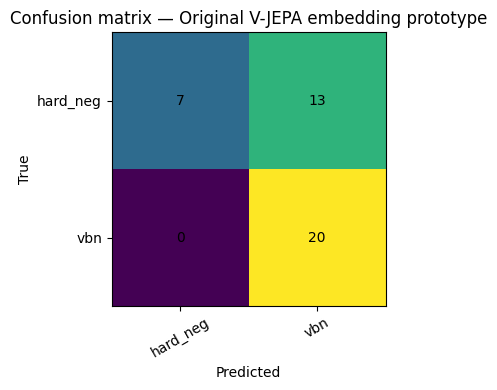

,sample_id,true_label,original_vacant_prob,original_pred_label
0,sample_000002,1,0.533290,1
1,sample_000011,1,0.522505,1
2,sample_000019,1,0.522505,1
3,sample_000024,1,0.533290,1
4,sample_000027,1,0.511501,1


In [11]:
# -----------------------------------------------------------------------------
# Step 10. Original pretrained V-JEPA baseline
# -----------------------------------------------------------------------------
# This cell evaluates the frozen pretrained V-JEPA representation before any
# downstream head is trained.
#
# Procedure:
# - collect train and validation embeddings from the frozen backbone;
# - L2-normalize embeddings;
# - build one prototype per class by averaging train embeddings;
# - classify validation embeddings by cosine similarity to class prototypes;
# - convert similarities to probabilities with temperature softmax;
# - report metrics and save a confusion matrix.
#
# This is not a zero-shot classifier, because train labels are used to create the
# prototypes. However, no neural-network weights are updated. It measures how
# well the original V-JEPA embedding geometry separates VBN positives from nearby
# hard negatives.
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    accuracy_score,
)

@torch.no_grad()
def collect_embeddings(loader, name: str = "loader"):
    backbone.eval()

    all_embeddings = []
    all_labels = []
    all_ids = []

    for videos, labels, ids in tqdm(loader, desc=f"Collect embeddings: {name}", leave=False):
        feat, _ = encode_batch(videos)
        all_embeddings.append(feat.detach().cpu())
        all_labels.append(labels.detach().cpu())
        all_ids.extend(list(ids))

    return {
        "embeddings": torch.cat(all_embeddings).numpy(),
        "labels": torch.cat(all_labels).numpy(),
        "ids": all_ids,
    }


def l2_normalize_np(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)


def prototype_predict_proba(
    train_embeddings: np.ndarray,
    train_labels: np.ndarray,
    eval_embeddings: np.ndarray,
    temperature: float = 0.07,
) -> np.ndarray:
    # No-gradient prototype classifier on frozen V-JEPA embeddings.
    # It creates one normalized centroid per class from train embeddings,
    # then returns softmax probabilities from cosine similarities.
    classes = np.array(sorted(np.unique(train_labels)))
    if len(classes) != 2:
        raise RuntimeError(f"Expected two classes, got: {classes}")

    x_train = l2_normalize_np(train_embeddings)
    x_eval = l2_normalize_np(eval_embeddings)

    prototypes = []
    for cls in classes:
        proto = x_train[train_labels == cls].mean(axis=0, keepdims=True)
        proto = l2_normalize_np(proto)[0]
        prototypes.append(proto)

    prototypes = np.stack(prototypes, axis=0)  # [2, D]
    logits = x_eval @ prototypes.T
    logits = logits / temperature

    logits = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)

    # classes are expected to be [0, 1], so probs[:, 1] is vacant probability.
    return probs


def summarize_binary_predictions(
    name: str,
    y_true: np.ndarray,
    probs: np.ndarray,
    fig_path: Path | None = None,
):
    y_pred = probs.argmax(axis=1)

    summary = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": np.nan,
        "average_precision": np.nan,
    }

    if len(np.unique(y_true)) == 2:
        try:
            summary["roc_auc"] = roc_auc_score(y_true, probs[:, 1])
        except Exception:
            pass
        try:
            summary["average_precision"] = average_precision_score(y_true, probs[:, 1])
        except Exception:
            pass

    print(f"\n=== {name} ===")
    print(pd.Series(summary))
    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["hard_negative_proxy", "vacant_building_notice"],
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"Confusion matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["hard_neg", "vbn"], rotation=30)
    plt.yticks([0, 1], ["hard_neg", "vbn"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    if fig_path is not None:
        plt.savefig(fig_path, dpi=160)
    plt.show()

    return summary


# Collect embeddings once from the original pretrained V-JEPA backbone.
original_train = collect_embeddings(train_loader, name="train / original V-JEPA")
original_val = collect_embeddings(val_loader, name="val / original V-JEPA")

original_probs = prototype_predict_proba(
    original_train["embeddings"],
    original_train["labels"],
    original_val["embeddings"],
    temperature=0.07,
)

original_summary = summarize_binary_predictions(
    "Original V-JEPA embedding prototype",
    original_val["labels"],
    original_probs,
    fig_path=FIG_DIR / "confusion_matrix_original_vjepa_prototype_clean_v4.png",
)

original_val_pred_df = pd.DataFrame({
    "sample_id": original_val["ids"],
    "true_label": original_val["labels"],
    "original_vacant_prob": original_probs[:, 1],
    "original_pred_label": original_probs.argmax(axis=1),
})

display(original_val_pred_df.head())

## 11. Train downstream MLP head


In [12]:
# -----------------------------------------------------------------------------
# Step 11. Train downstream MLP head
# -----------------------------------------------------------------------------
# This cell trains a small supervised MLP head on top of frozen V-JEPA embeddings.
#
# Architecture:
#   V-JEPA pooled embedding [B, IN_DIM]
#   -> LayerNorm
#   -> Linear(IN_DIM, 512)
#   -> GELU
#   -> Dropout
#   -> Linear(512, 2)
#
# Only the head is trainable. The V-JEPA backbone remains in eval mode and is
# called under torch.no_grad(). The training objective is cross-entropy over the
# two labels: nearby hard negative vs vacant building notice.
#
# The goal is to learn a supervised decision boundary that improves on the
# prototype baseline, especially by reducing hard-negative false positives while
# preserving VBN recall as much as possible.
# -----------------------------------------------------------------------------

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, balanced_accuracy_score
from tqdm.auto import tqdm

class VJEPAVacancyHead(nn.Module):
    def __init__(self, in_dim: int, num_classes: int = 2):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(in_dim), nn.Linear(in_dim, 512), nn.GELU(), nn.Dropout(0.25), nn.Linear(512, num_classes))
    def forward(self, x):
        return self.net(x)

if "IN_DIM" not in globals():
    raise RuntimeError("IN_DIM is missing. Run Step 9 first.")

head = VJEPAVacancyHead(IN_DIM, num_classes=2).to(device)
optimizer = torch.optim.AdamW(head.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, train: bool):
    head.train(train)
    backbone.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_probs, all_labels, all_ids, all_embeddings = [], [], [], []
    pbar = tqdm(loader, desc="train" if train else "val", leave=False)
    for videos, labels, ids in pbar:
        labels = labels.to(device)
        with torch.no_grad():
            feat, _ = encode_batch(videos)
        logits = head(feat)
        loss = criterion(logits, labels)
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        probs = torch.softmax(logits.detach(), dim=-1)
        pred = probs.argmax(dim=-1)
        total_loss += loss.item() * labels.numel()
        correct += (pred == labels).sum().item()
        total += labels.numel()
        all_probs.append(probs.cpu())
        all_labels.append(labels.detach().cpu())
        all_embeddings.append(feat.detach().cpu())
        all_ids.extend(list(ids))
        pbar.set_postfix(loss=float(loss.item()), acc=correct / max(total, 1))
    return {"loss": total_loss / max(total, 1), "acc": correct / max(total, 1), "probs": torch.cat(all_probs).numpy(), "labels": torch.cat(all_labels).numpy(), "embeddings": torch.cat(all_embeddings).numpy(), "ids": all_ids}

history = []
best_val_loss = float("inf")
for epoch in range(EPOCHS):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)
    row = {"epoch": epoch, "train_loss": tr["loss"], "train_acc": tr["acc"], "val_loss": va["loss"], "val_acc": va["acc"]}
    history.append(row)
    print(row)
    if va["loss"] < best_val_loss:
        best_val_loss = va["loss"]
        torch.save({"head_state_dict": head.state_dict(), "in_dim": IN_DIM, "img_size": IMG_SIZE, "t_frames": T_FRAMES, "class_names": ["nearby_hard_negative_proxy", "vacant_building_notice"], "checkpoint_url": VJEPA21_VITB_CKPT_URL, "note": "V-JEPA 2.1 ViT-B/384 frozen backbone + MLP head; clean v3"}, CKPT_DIR / "vjepa21_vitb_vacancy_head_clean_v3.pt")

history_df = pd.DataFrame(history)
display(history_df)


train:   0%|          | 0/80 [00:00<?, ?it/s]

/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


val:   0%|          | 0/20 [00:00<?, ?it/s]

{'epoch': 0, 'train_loss': 0.6541731307283044, 'train_acc': 0.59375, 'val_loss': 0.5769115652889013, 'val_acc': 0.7}


train:   0%|          | 0/80 [00:00<?, ?it/s]

...

{'epoch': 1, 'train_loss': 0.5369838091544807, 'train_acc': 0.7375, 'val_loss': 0.5945649173110723, 'val_acc': 0.725}


train:   0%|          | 0/80 [00:00<?, ?it/s]

val:   0%|          | 0/20 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.49570016281795687, 'train_acc': 0.75, 'val_loss': 0.5403947804123164, 'val_acc': 0.725}


,epoch,train_loss,train_acc,val_loss,val_acc
0,0,0.654173,0.59375,0.576912,0.700
1,1,0.536984,0.73750,0.594565,0.725
2,2,0.495700,0.75000,0.540395,0.725


## 12. Evaluate and compare original vs fine-tuned outputs

val:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)



=== Fine-tuned MLP head on V-JEPA embeddings ===
model                Fine-tuned MLP head on V-JEPA embeddings
accuracy                                                0.725
balanced_accuracy                                       0.725
roc_auc                                                 0.805
average_precision                                    0.804481
dtype: object

Classification report:
                        precision    recall  f1-score   support

   hard_negative_proxy       0.85      0.55      0.67        20
vacant_building_notice       0.67      0.90      0.77        20

              accuracy                           0.72        40
             macro avg       0.76      0.73      0.72        40
          weighted avg       0.76      0.72      0.72        40



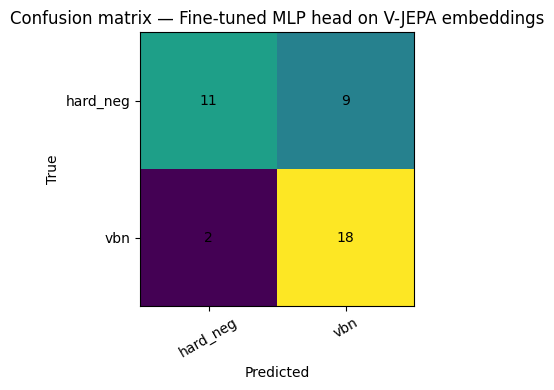

,model,accuracy,balanced_accuracy,roc_auc,average_precision
0,Original V-JEPA embedding prototype,0.675,0.675,0.7575,0.757574
1,Fine-tuned MLP head on V-JEPA embeddings,0.725,0.725,0.8050,0.804481


Saved comparison: vjepa21_vacancy_clean_v3/outputs/original_vs_finetuned_metrics_clean_v4.csv


,sample_id,true_label,original_vacant_prob,original_pred_label,fine_tuned_vacant_prob,fine_tuned_pred_label,prob_delta_finetuned_minus_original
0,sample_000002,1,0.533290,1,0.869865,1,0.336575
1,sample_000011,1,0.522505,1,0.703646,1,0.181141
2,sample_000019,1,0.522505,1,0.703646,1,0.181141
3,sample_000024,1,0.533290,1,0.869865,1,0.336575
4,sample_000027,1,0.511501,1,0.467030,0,-0.044472


Saved prediction comparison: vjepa21_vacancy_clean_v3/outputs/original_vs_finetuned_predictions_clean_v4.csv


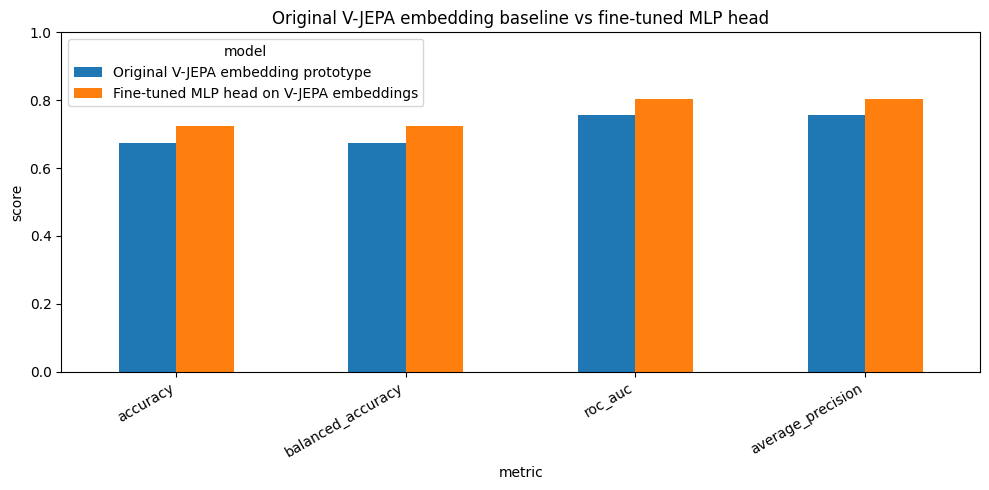

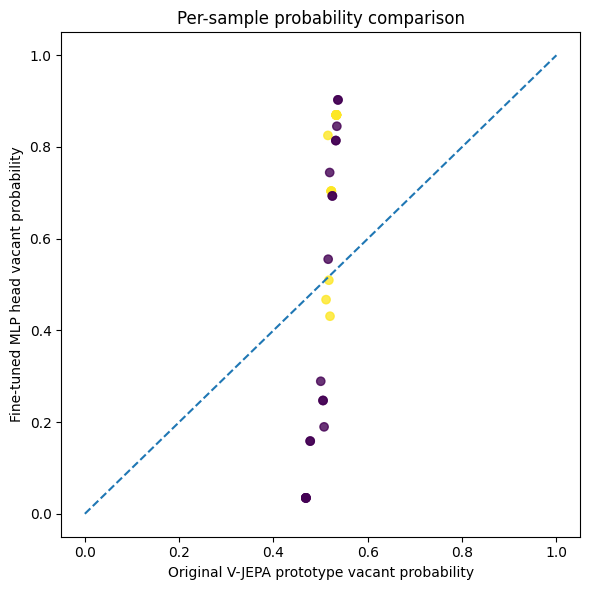

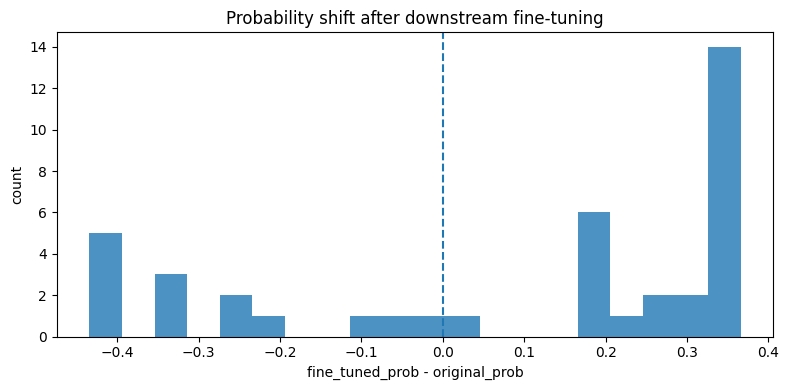

In [13]:
# -----------------------------------------------------------------------------
# Step 12. Evaluate and compare original vs fine-tuned outputs
# -----------------------------------------------------------------------------
# This cell compares the original prototype baseline against the trained MLP head
# on the same validation set.
#
# It:
# - evaluates the fine-tuned head on validation data;
# - computes accuracy, balanced accuracy, ROC-AUC, average precision, and a
#   confusion matrix;
# - creates a metrics comparison table;
# - saves per-sample original and fine-tuned vacant probabilities;
# - computes the probability shift introduced by the downstream head;
# - saves bar/scatter/histogram plots for model-level and sample-level analysis.
#
# The key diagnostic is whether the MLP head reduces false positives among nearby
# hard negatives without sacrificing too much recall on VBN positives.
# -----------------------------------------------------------------------------

val_metrics = run_epoch(val_loader, train=False)

y_true = val_metrics["labels"]
fine_tuned_probs = val_metrics["probs"]
fine_tuned_pred = fine_tuned_probs.argmax(axis=1)

fine_tuned_summary = summarize_binary_predictions(
    "Fine-tuned MLP head on V-JEPA embeddings",
    y_true,
    fine_tuned_probs,
    fig_path=FIG_DIR / "confusion_matrix_finetuned_head_clean_v4.png",
)

comparison_df = pd.DataFrame([original_summary, fine_tuned_summary])
display(comparison_df)

comparison_path = OUT_DIR / "original_vs_finetuned_metrics_clean_v4.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved comparison:", comparison_path)

fine_tuned_val_pred_df = pd.DataFrame({
    "sample_id": val_metrics["ids"],
    "true_label": y_true,
    "fine_tuned_vacant_prob": fine_tuned_probs[:, 1],
    "fine_tuned_pred_label": fine_tuned_pred,
})

prediction_compare_df = original_val_pred_df.merge(
    fine_tuned_val_pred_df,
    on=["sample_id", "true_label"],
    how="inner",
)

prediction_compare_df["prob_delta_finetuned_minus_original"] = (
    prediction_compare_df["fine_tuned_vacant_prob"]
    - prediction_compare_df["original_vacant_prob"]
)

display(prediction_compare_df.head())

prediction_compare_path = OUT_DIR / "original_vs_finetuned_predictions_clean_v4.csv"
prediction_compare_df.to_csv(prediction_compare_path, index=False)
print("Saved prediction comparison:", prediction_compare_path)

metric_cols = ["accuracy", "balanced_accuracy", "roc_auc", "average_precision"]
plot_df = comparison_df.set_index("model")[metric_cols]

ax = plot_df.T.plot(kind="bar", figsize=(10, 5), ylim=(0, 1))
ax.set_title("Original V-JEPA embedding baseline vs fine-tuned MLP head")
ax.set_ylabel("score")
ax.set_xlabel("metric")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "original_vs_finetuned_metrics_bar_clean_v4.png", dpi=160)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(
    prediction_compare_df["original_vacant_prob"],
    prediction_compare_df["fine_tuned_vacant_prob"],
    c=prediction_compare_df["true_label"],
    alpha=0.8,
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Original V-JEPA prototype vacant probability")
plt.ylabel("Fine-tuned MLP head vacant probability")
plt.title("Per-sample probability comparison")
plt.tight_layout()
plt.savefig(FIG_DIR / "original_vs_finetuned_probability_scatter_clean_v4.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(
    prediction_compare_df["prob_delta_finetuned_minus_original"],
    bins=20,
    alpha=0.8,
)
plt.axvline(0.0, linestyle="--")
plt.xlabel("fine_tuned_prob - original_prob")
plt.ylabel("count")
plt.title("Probability shift after downstream fine-tuning")
plt.tight_layout()
plt.savefig(FIG_DIR / "probability_delta_histogram_clean_v4.png", dpi=160)
plt.show()

## 13. Embedding PCA


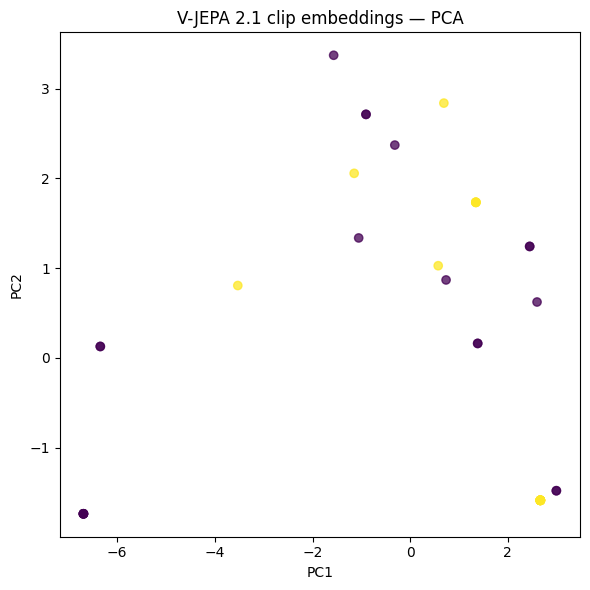

In [14]:
# -----------------------------------------------------------------------------
# Step 13. Embedding PCA
# -----------------------------------------------------------------------------
# This cell projects validation embeddings into two principal components for
# visual inspection. The goal is to see whether hard negatives and VBN positives
# occupy separable regions in the frozen V-JEPA feature space and/or after the
# downstream workflow.
#
# PCA is only a diagnostic visualization. It should not be treated as the main
# metric, because high-dimensional separability can be lost in a 2D projection.
# -----------------------------------------------------------------------------

from sklearn.decomposition import PCA
X = val_metrics["embeddings"]
y = val_metrics["labels"]
if len(X) >= 2:
    Z = PCA(n_components=2, random_state=SEED).fit_transform(X)
    plt.figure(figsize=(6, 6))
    plt.scatter(Z[:, 0], Z[:, 1], c=y, alpha=0.75)
    plt.title("V-JEPA 2.1 clip embeddings — PCA")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "embedding_pca_clean_v3.png", dpi=160)
    plt.show()
else:
    print("Not enough validation embeddings for PCA.")


## 14. Prediction map and spatial split map


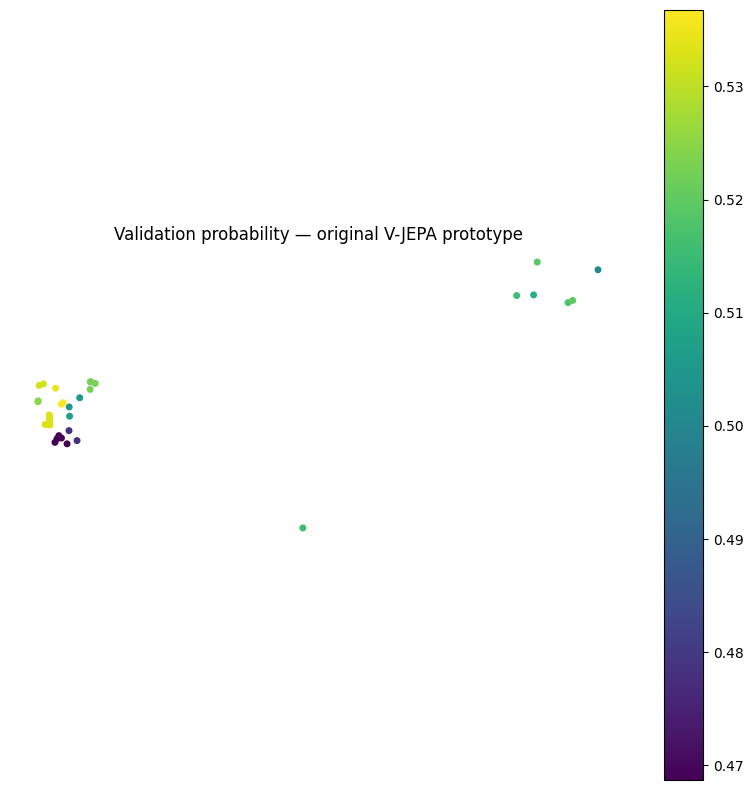

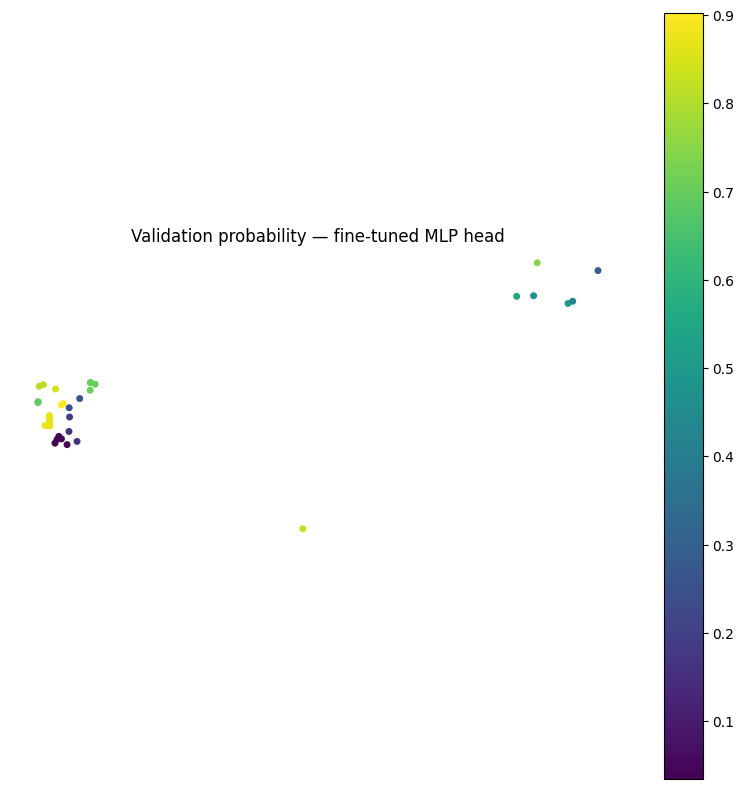

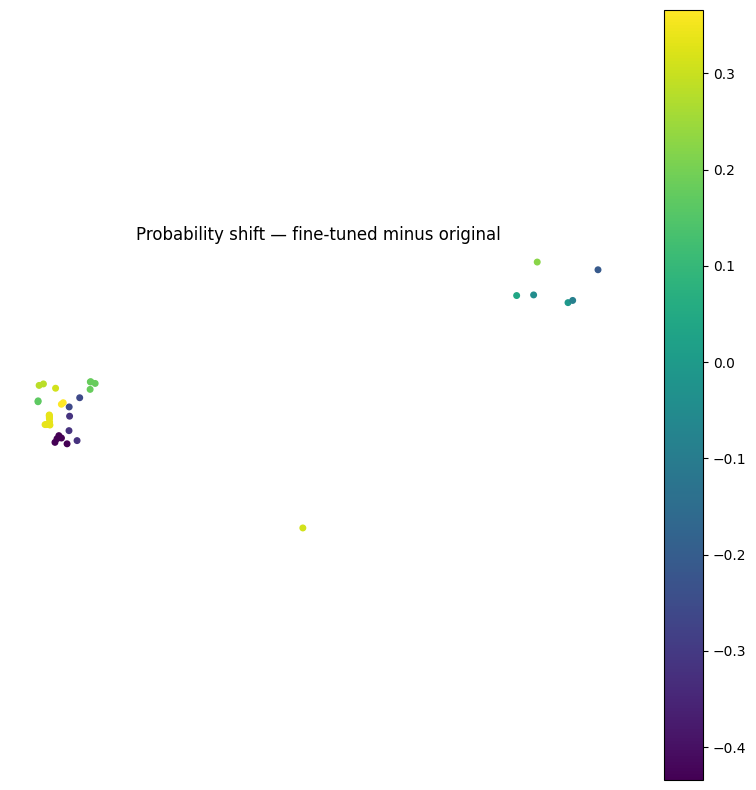

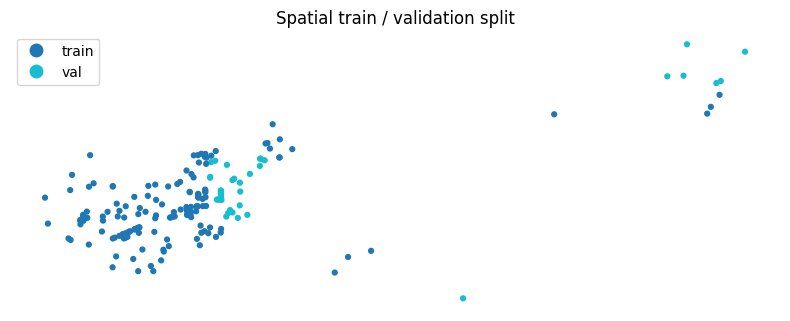

In [15]:
# -----------------------------------------------------------------------------
# Step 14. Prediction map and spatial split map
# -----------------------------------------------------------------------------
# This cell visualizes model predictions and the spatial split geographically.
#
# It helps answer questions such as:
# - where the original prototype assigns high VBN probability;
# - where the fine-tuned head changes the probability most;
# - whether prediction errors cluster spatially;
# - whether train/validation regions are spatially separated as intended.
#
# These maps are diagnostic tools for geospatial leakage, regional bias, and
# failure-mode analysis.
# -----------------------------------------------------------------------------

# Map comparison: original probability, fine-tuned probability, and probability shift.

if "prediction_compare_df" not in globals():
    raise RuntimeError("prediction_compare_df is missing. Run Step 12 first.")

map_df = manifest_split.merge(prediction_compare_df, on="sample_id", how="left")

map_gdf = gpd.GeoDataFrame(
    map_df,
    geometry=gpd.points_from_xy(map_df["lon"], map_df["lat"]),
    crs="EPSG:4326",
)

val_map = map_gdf[map_gdf["split"] == "val"].copy()

for column, title, filename in [
    (
        "original_vacant_prob",
        "Validation probability — original V-JEPA prototype",
        "validation_probability_original_vjepa_clean_v4.png",
    ),
    (
        "fine_tuned_vacant_prob",
        "Validation probability — fine-tuned MLP head",
        "validation_probability_finetuned_head_clean_v4.png",
    ),
    (
        "prob_delta_finetuned_minus_original",
        "Probability shift — fine-tuned minus original",
        "validation_probability_delta_clean_v4.png",
    ),
]:
    ax = val_map.plot(
        column=column,
        figsize=(8, 8),
        markersize=16,
        legend=True,
    )
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=160)
    plt.show()

ax = map_gdf.plot(
    column="split",
    figsize=(8, 8),
    markersize=12,
    legend=True,
)
ax.set_title("Spatial train / validation split")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG_DIR / "spatial_split_map_clean_v4.png", dpi=160)
plt.show()

## 15. Patch-token PCA overlay


/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


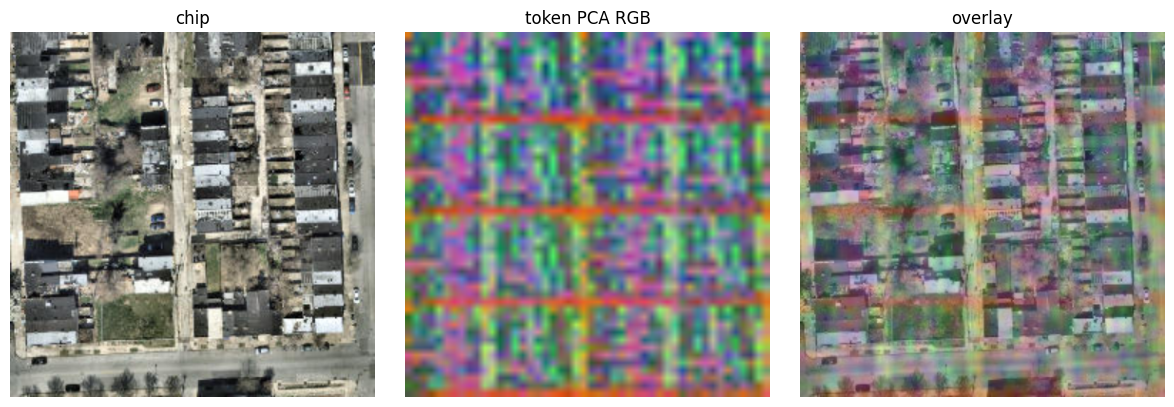

In [16]:
# -----------------------------------------------------------------------------
# Step 15. Patch-token PCA overlay
# -----------------------------------------------------------------------------
# This cell creates a qualitative token-level visualization from V-JEPA features.
#
# It reduces patch/token representations to RGB-like PCA components and overlays
# or displays them to inspect what parts of an image chip contribute to the
# representation. This is not a calibrated explanation method, but it can reveal
# whether token structure varies around buildings, roads, lots, or other visible
# urban patterns.
# -----------------------------------------------------------------------------

def tokens_to_pca_rgb(tokens_2d: torch.Tensor) -> np.ndarray:
    arr = tokens_2d.detach().cpu().numpy()
    if arr.shape[0] < 3:
        raise RuntimeError("Need at least 3 tokens for PCA RGB.")
    rgb = PCA(n_components=3, random_state=SEED).fit_transform(arr)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return (rgb * 255).astype(np.uint8)

def make_patch_overlay(row):
    ds = ChipPseudoVideoDataset(pd.DataFrame([row]), train=False)
    video, label, sid = ds[0]
    with torch.no_grad():
        _, token_features = encode_batch(video.unsqueeze(0))
    if token_features.ndim == 3:
        toks = token_features[0]
    elif token_features.ndim == 4:
        toks = token_features[0].reshape(-1, token_features.shape[-1])
    else:
        raise ValueError(f"Unexpected token feature shape: {token_features.shape}")
    rgb = tokens_to_pca_rgb(toks)
    n = rgb.shape[0]
    side = int(math.sqrt(n))
    if side * side == n:
        rgb_map = rgb.reshape(side, side, 3)
    else:
        rgb_map = rgb.reshape(1, n, 3)
    chip = Image.open(row.chip_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    rgb_img = Image.fromarray(rgb_map).resize((IMG_SIZE, IMG_SIZE), resample=Image.Resampling.BILINEAR)
    overlay = Image.blend(chip, rgb_img, alpha=0.45)
    return chip, rgb_img, overlay

example_row = val_df.iloc[0] if len(val_df) > 0 else manifest_split.iloc[0]
chip, rgb_img, overlay = make_patch_overlay(example_row)
plt.figure(figsize=(12, 4))
for i, (title, img) in enumerate([("chip", chip), ("token PCA RGB", rgb_img), ("overlay", overlay)]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "patch_token_pca_overlay_clean_v3.png", dpi=160)
plt.show()


## 16. Notes and next steps

How to interpret the comparison:

```text
Original V-JEPA prototype baseline:
  Tests whether pretrained V-JEPA embeddings already separate the two classes.

Fine-tuned MLP head:
  Tests whether a small supervised head can reshape the decision boundary
  on top of the same frozen V-JEPA embeddings.
```

If the fine-tuned head improves AUC/AP over the prototype baseline, the downstream labels add useful task-specific supervision.
If it does not improve, the pretrained embedding geometry is already doing most of the work, or the dataset is too small/noisy.

If the result is still too easy or unstable, make the task harder in this order:

1. Increase `MAX_POSITIVES` and `MAX_NEGATIVES` to 500–1000.
2. Increase spatial holdout distance by using larger `GRID_SIZE_M`, e.g. 1200–2000.
3. Replace random nearby hard negatives with confirmed non-vacant parcels/buildings.
4. Use multi-year imagery instead of pseudo-video jitter.
5. Aggregate predictions to census tract level and join ACS B25002:

```text
tract_vacancy_rate = vacant_housing_units / total_housing_units
```

Then train a tract-level regression model:

```text
V-JEPA image embeddings
+ building-level vacant probabilities
+ demographic / road / POI features
→ tract-level vacancy_rate
```